# Lab 7.05 - Time series analysis

In [2]:
# Package imports
import pandas as pd


### Exercise 5 - Alcoholic beverages sales

The file US Retail.csv contains monthly retail sales of beer, wine, and liquor at U.S. liquor stores.

- Is seasonality present in these data?
- Create a time series chart of the data. Based on what you see, which of the exponential smoothing models do you think should be used for forecasting? Why?
- Split the dataset in a train (1992-01-01 up to and including 2008-12-01) and test set (2009-01-01 up to and including 2009-12-01)  
- Create and train the model.
- Predict the values for 2009.
- Create a plot with the train data, the fitted values, the test data and the predicted values.
- Calculate MAE

In [3]:
data = pd.read_csv('https://raw.githubusercontent.com/HoGentTIN/dsai-labs/main/data/US%20Retail.csv', delimiter = ";", parse_dates=['Month']).set_index(['Month'])
data.head()

,Total Sales
Month,
1992-01-01,1519
1992-02-01,1551
1992-03-01,1606
1992-04-01,1686
1992-05-01,1834


<Axes: xlabel='Month'>

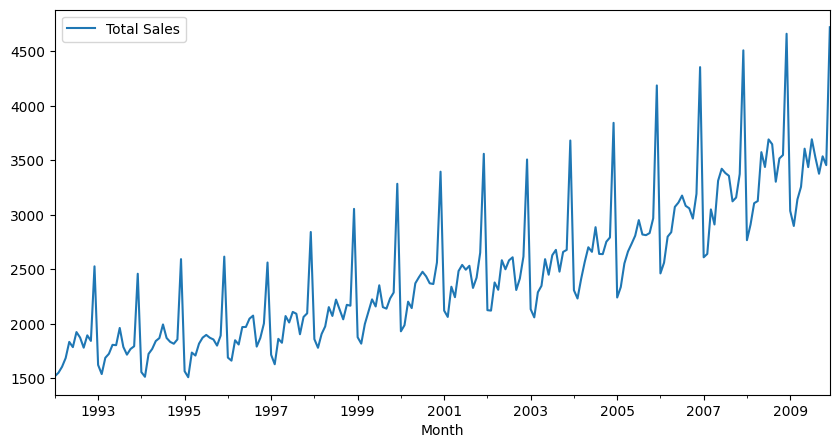

In [8]:
data.plot(y='Total Sales', figsize=[10,5])

In [12]:
train_data = data[:'2008-12-01']
test_data = data['2009-01-01':]

# train_data.tail()
# test_data.tail()

In [17]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Multiplicative!
train_data_tes = ExponentialSmoothing(train_data, trend='add', seasonal='multiplicative', seasonal_periods=12, freq='MS').fit()
train_data_tes_fc = train_data_tes.forecast(12)

train_data_tes_fc

,0
2009-01-01,2969.920841
2009-02-01,2966.259788
2009-03-01,3280.295971
2009-04-01,3300.551838
2009-05-01,3607.343262
2009-06-01,3588.294070
2009-07-01,3747.371829
2009-08-01,3654.558014
2009-09-01,3459.985061
2009-10-01,3565.734069


<Axes: xlabel='Month'>

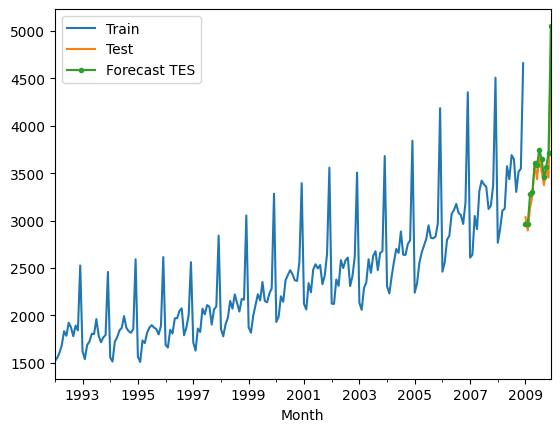

In [21]:
train_data['Total Sales'].plot(legend=True, label='Train')
test_data['Total Sales'].plot(legend=True, label='Test')
train_data_tes_fc.plot(marker='.', legend=True, label='Forecast TES')

In [24]:
from sklearn.metrics import mean_absolute_error

y_true = test_data.values
y_pred = train_data_tes_fc.values
mean_absolute_error(y_true, y_pred)

113.71209743310392

## Source
Business Analytics Data Analysis & Decision Making